# **APRENDIZAGEM SUPERVISIONADA: CLASSIFICAÇÃO**

Este notebook tem por objetivo demonstrar o treinamento e a avaliação de um algoritmo de Machine Learning de classificação.

Os dados são gerados artificialmente com `sklearn.datasets.make_moons`, que cria duas classes em formato de "lua" entrelaçadas — de propósito, NÃO separáveis por uma única reta. Isso deixa visualmente clara a diferença entre as fronteiras de decisão de cada família de classificador:

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html

# **PRÉ-PROCESSAMENTO**

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Dataset sintetico: duas classes em forma de "lua", que NAO podem ser
# separadas por uma unica reta - de proposito, para expor a diferenca
# entre fronteiras lineares e nao lineares.
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

In [3]:
df = pd.DataFrame(X, columns=['x1', 'x2'])
df['classe'] = y
df.head()

,x1,x2,classe
0,0.864396,-0.264509,1
1,2.451154,-0.117550,1
2,-0.350712,0.449211,1
3,0.741296,0.432919,0
4,1.188756,-0.518301,1


In [4]:
df.shape

(300, 3)

In [5]:
df['classe'].value_counts()

classe
1    150
0    150
Name: count, dtype: int64

## **Separação em treino/teste e escalonamento**

In [6]:
# Separando os dados em treino (70%) e teste (30%)
x_treino, x_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.30, random_state=0
)

# Escalonamento ajustado (fit) SOMENTE no treino; o teste só passa por transform
scaler = StandardScaler()
x_treino = scaler.fit_transform(x_treino)
x_teste = scaler.transform(x_teste)

In [7]:
x_treino.shape

(210, 2)

In [8]:
x_teste.shape

(90, 2)

In [9]:
y_treino.shape

(210,)

In [10]:
y_teste.shape

(90,)

# **APRENDIZAGEM BASEADA EM INSTÂNCIAS (KNN)**

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [11]:
from sklearn.neighbors import KNeighborsClassifier

### **Validação Cruzada**

In [12]:
from sklearn.model_selection import KFold, cross_validate

# Separando os dados em folds
kfold = KFold(n_splits = 20, shuffle=True, random_state = 0)

In [13]:
# Reaproveitando a separação treino/teste e o escalonamento já feitos no
# pré-processamento (x_treino, x_teste, y_treino, y_teste).

In [14]:
x_treino.shape

(210, 2)

In [15]:
# Criação do modelo
modelo = KNeighborsClassifier(n_neighbors=11, metric='minkowski', p = 1)

# Validação cruzada
resultado = cross_validate(modelo, x_treino, y_treino, cv = kfold, return_train_score=True)

In [16]:
# Resultados e comparação
print("Acurácia de Treino (Média):", resultado['train_score'].mean())
print("Acurácia de Validação (Média):", resultado['test_score'].mean())

Acurácia de Treino (Média): 0.9218002512562815
Acurácia de Validação (Média): 0.9136363636363635


Naive Bayes = 85,82% (validação cruzada), 85,71% (treino) e 86,67% (teste) - 78 acertos

SVM = 89,55% (validação cruzada), 90,00% (treino) e 91,11% (teste) - 82 acertos - SVC(kernel='rbf', random_state=0, C = 2)

Regressão logística = 85,82% (validação cruzada), 85,71% (treino) e 87,78% (teste) - 79 acertos - LogisticRegression(random_state=0, max_iter=600, tol=0.0001, C=1, solver="lbfgs")

KNN = 91,36% (validação cruzada), 91,90% (treino) e 95,56% (teste) - 86 acertos - KNeighborsClassifier(n_neighbors=11, metric='minkowski', p = 1)



In [17]:
# Treinamento com dados de treino completo
knn = KNeighborsClassifier(n_neighbors=11, metric='minkowski', p=1)
knn.fit(x_treino, y_treino)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'ma...an'


https://scikit-learn.org/stable/modules/generated/sklearn.metrics.DistanceMetric.html

In [18]:
previsoes_knn = knn.predict(x_teste)
previsoes_knn

array([0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0])

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [20]:
print("Acurácia: %.2f%%" % (accuracy_score(y_teste, previsoes_knn) * 100.0))

Acurácia: 95.56%


In [21]:
confusion_matrix(y_teste, previsoes_knn)

array([[38,  1],
       [ 3, 48]])

**Análise dados de treino**

In [22]:
previsoes_treino = knn.predict(x_treino)
previsoes_treino

array([1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1])

In [23]:
accuracy_score(y_treino, previsoes_treino)

0.919047619047619

### **Fronteira de decisão**

Região azul = pontos que o modelo classificaria como classe 0; região vermelha = classe 1. Os pontos são os dados de teste, coloridos pela classe REAL — pontos numa região da cor errada são os erros do modelo. Repare no contorno irregular, sensível a cada vizinhança local.

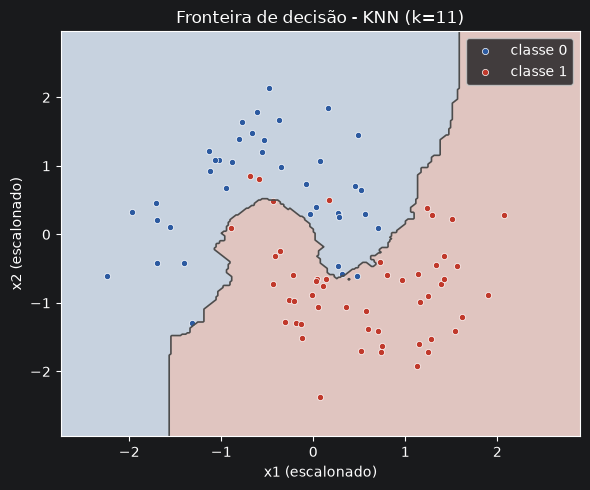

In [24]:
import matplotlib.pyplot as plt

# Malha de pontos cobrindo toda a area dos dados (treino + teste), para
# colorir cada regiao conforme a classe que o modelo preveria ali
X_plot = np.vstack([x_treino, x_teste])
xx, yy = np.meshgrid(
    np.linspace(X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5, 300),
    np.linspace(X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = knn.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=["#dbe7f6", "#f7d9d3"], alpha=0.9)
ax.contour(xx, yy, Z, levels=[0.5], colors="#4c4c4c", linewidths=1.2)

cores_pontos = ["#2c5aa0", "#c0392b"]
for classe, cor in zip([0, 1], cores_pontos):
    pts = x_teste[y_teste == classe]
    ax.scatter(pts[:, 0], pts[:, 1], c=cor, s=20, edgecolors="white",
               linewidths=0.5, label=f"classe {classe}")

ax.set_title("Fronteira de decisão - KNN (k=11)")
ax.set_xlabel("x1 (escalonado)")
ax.set_ylabel("x2 (escalonado)")
ax.legend()
fig.tight_layout()
plt.show()